In [1]:
# Initialisers
import sympy as sp
import matplotlib.pyplot as plt

# Adjoint
def dagger(A):
    return A.conjugate().T

# Kronecker tensor product
def kron(A, B):
    return sp.kronecker_product(A, B)

# Hadamard
H = (1 / sp.sqrt(2)) * sp.Matrix([[1,  1],
                                [1, -1]])

# Identity
I_coin = sp.eye(2)

**1. Calculating p(t) for a certain target node after t steps, starting at some initial position.**

In [2]:
# Choose values for the target node, initial position, and the number of time steps
target = eval(input("Enter target node: "))
init_pos = eval(input("Enter initial position: "))
t = eval(input("Enter number of time steps: "))


L = 100
Npos = 2 * L + 1 # Positions -L to L
Ncoin = 2 # Dimension 2-D
dim = Npos * Ncoin

# Map positions to indices
def pos_index(i):
    return i + L

# Shift operator
S = sp.zeros(dim, dim)
for i in range(-L, L + 1):
    if i + 1 <= L:
        S[2 * pos_index(i + 1), 2 * pos_index(i)] = 1 # Move right
    if i - 1 >= -L:
        S[2 * pos_index(i - 1) + 1, 2 * pos_index(i) + 1] = 1 # Move left


# Unitary
U = S * kron(sp.eye(Npos), H)

# Projection operator P
P_pos = sp.zeros(Npos, Npos)
P_pos[pos_index(target), pos_index(target)] = 1
P = kron(P_pos, I_coin)

# Projection operator Q
Q = sp.eye(dim) - P

# Define the initial state
rho_pos = sp.zeros(Npos, Npos)
rho_pos[pos_index(init_pos), pos_index(init_pos)] = 1
rho_coin =  sp.Rational(1, 2) * sp.Matrix([[1, -1],
                                         [-1, 1]]) # Changeable spin state
rho0 = kron(rho_pos, rho_coin)

# Set value for p(0) depending on target
if init_pos == target:
                if t == 0:
                    p_t = 1.0
                else:
                    p_t = 0.0

# p(t) otherwise
else:
    QU = Q * U
    QU_t1 = QU ** (t - 1) # Not hitting target node
    A = P * U * QU_t1 # PU = hitting target node for the first time
    B = dagger(A) # Adjoint of A
    p_t = sp.trace(A * rho0 * B) # Taking the trace

# Print p(t) for specified values
print(f"p({t}) =", p_t)


Enter target node: 1
Enter initial position: 0
Enter number of time steps: 1
p(1) = 0


**2. Plot a graph of p(t) vs. t for the previous initial node and target node for a specified number of time steps.**

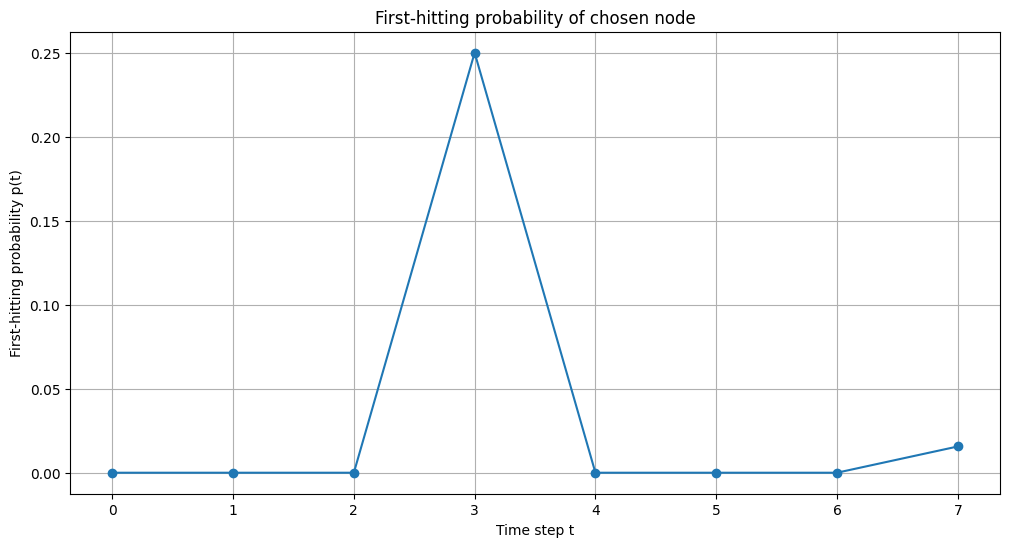

In [3]:
# Create a space for p(t) values to append to
p_vals = []

# Specify a range of times to plot
times = range(0, 8)

for time_step in times:
    if time_step == 0:
        if init_pos == target:
            p_t = 1.0
        else:
            p_t = 0.0

    else:
        A = P * U * (Q * U) ** (time_step - 1)
        B = dagger(A)
        p_t = sp.trace(A * rho0 * B)

    p_vals.append(float(p_t))

# Plot p(t) vs. t
plt.figure(figsize=(12, 6))
plt.plot(times, p_vals, marker='o')
plt.xlabel("Time step t")
plt.ylabel("First-hitting probability p(t)")
plt.title("First-hitting probability of chosen node")
plt.grid()
plt.show()